# AI-ML Assignment 1 : Medical Insurance Cost Prediction using Multiple Linear Regression



**Objective:** Build a Multiple Linear Regression model that predicts a person's medical
insurance `charges` from their personal and health information (age, sex, BMI, number of
children, smoking status, and region).

**Dataset:** [Medical Cost Personal Insurance Dataset on Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance)
(1338 rows, 7 columns)

---


In [1]:
# Import pandas — this is the main library we use to load and work with tabular data (like Excel sheets, but in code)
import pandas as pd

# The URL below points to a raw CSV file on GitHub that is an exact mirror of the Kaggle
# "Medical Cost Personal Insurance Dataset". Since it's raw text (not a webpage), pandas can
# read it directly over the internet using pd.read_csv().
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

# pd.read_csv() reads the CSV file at that URL and turns it into a DataFrame
# (think of a DataFrame as a spreadsheet stored in memory that we can manipulate with code)
df = pd.read_csv(url)

# ---------------------------------------------------------------------------
# ALTERNATIVE: If you prefer to download the official file from Kaggle directly,
# uncomment and run the lines below INSTEAD of the two lines above.
# You will need a Kaggle account and an API token (kaggle.json) uploaded to Colab.
# ---------------------------------------------------------------------------
# !pip install kaggle -q
# from google.colab import files
# files.upload()  # upload your kaggle.json here when prompted
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d mirichoi0218/insurance
# !unzip -o insurance.zip
# df = pd.read_csv("insurance.csv")

print("Dataset loaded successfully!")
print("Shape of dataset (rows, columns):", df.shape)


Dataset loaded successfully!
Shape of dataset (rows, columns): (1338, 7)


---

1. Load the dataset using Pandas (done above ✅)
2. Display the first five records
3. Identify numerical features, categorical features, and the target variable


In [2]:
# .head() shows the first 5 rows of the DataFrame by default — a quick sanity check
# to make sure the data loaded correctly and to see what the columns look like
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# .info() gives us a compact summary of the DataFrame:
# - the column names
# - how many non-null (non-missing) values each column has
# - the data type of each column (int64, float64, or object/string)
# This helps us immediately tell which columns are numerical vs categorical
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# .describe() gives summary statistics (mean, std, min, max, quartiles) for NUMERICAL columns only
# This helps us understand the range and distribution of values like age, bmi, charges, etc.
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Identifying feature types

Looking at the output above, we can classify the columns as follows:

| Column     | Type                        | Role              |
|------------|------------------------------|-------------------|
| `age`      | Numerical (int)              | Feature           |
| `sex`      | Categorical (2 categories)   | Feature           |
| `bmi`      | Numerical (float)            | Feature           |
| `children` | Numerical (int, discrete)    | Feature           |
| `smoker`   | Categorical (2 categories)   | Feature           |
| `region`   | Categorical (4 categories)   | Feature           |
| `charges`  | Numerical (float)             | **Target variable** |

- **Numerical features:** `age`, `bmi`, `children`
- **Categorical features:** `sex`, `smoker`, `region`
- **Target variable:** `charges` (the medical insurance cost we want to predict)


In [5]:
# We can also confirm this programmatically instead of just reading it off the table above.
# select_dtypes() lets us filter columns by their data type.

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# 'charges' is our target, so we remove it from the numerical FEATURE list
numerical_features.remove('charges')

categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target variable: charges")


Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']
Target variable: charges


---
 Data Preprocessing 


- Check for missing values
- Encode categorical variables (`sex`, `smoker`, `region`)
- Split the dataset into 80% training and 20% testing


In [6]:
# .isnull() marks every cell True if it's missing (NaN) and False otherwise.
# .sum() then adds up the True values per column, giving us a missing-value count per column.
print("Missing values in each column:")
print(df.isnull().sum())

# A quick check: if every value below is 0, the dataset is complete and needs no imputation.


Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


**Observation:** The dataset has **no missing values** in any column, so we don't need to
perform any imputation (filling in missing data). We can move straight to encoding.

### Encoding categorical variables

Machine learning models (including Linear Regression) only understand numbers, not text
labels like `"male"` or `"southeast"`. So we need to convert these text categories into
numeric form:

- `sex` has 2 categories (`male`, `female`) → we use **binary/label encoding** (0 or 1)
- `smoker` has 2 categories (`yes`, `no`) → we use **binary/label encoding** (0 or 1)
- `region` has 4 categories (`northeast`, `northwest`, `southeast`, `southwest`) → since there's
  no natural order between regions, we use **one-hot encoding** (a separate 0/1 column per
  region) instead of assigning arbitrary numbers, which would falsely imply an order.


In [7]:
# Make a copy of the original DataFrame so we always still have the raw, unedited data (df) available
df_encoded = df.copy()

# --- Binary encoding for 'sex' ---
# .map() replaces each text value with the number we specify in the dictionary
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})

# --- Binary encoding for 'smoker' ---
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})

# --- One-hot encoding for 'region' ---
# pd.get_dummies() creates a new 0/1 column for each category in 'region'.
# drop_first=True drops one of the columns (e.g. 'region_northeast') to avoid redundant/
# perfectly-correlated columns, which is called the "dummy variable trap".
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

# Let's look at the transformed data
df_encoded.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [8]:
# Separate our data into:
# X -> all the INPUT features the model will learn from (everything except 'charges')
# y -> the TARGET variable the model is trying to predict ('charges')
X = df_encoded.drop('charges', axis=1)   # axis=1 means "drop a column" (not a row)
y = df_encoded['charges']

print("Feature columns (X):", list(X.columns))
print("Target column (y): charges")


Feature columns (X): ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
Target column (y): charges


In [9]:
# train_test_split() randomly splits our data into a training set and a testing set.
# The model LEARNS from the training set, and we check how well it generalizes using the
# unseen testing set.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% of the data goes to testing, 80% stays for training
    random_state=42      # fixes the "randomness" so results are reproducible every time we run this
)

print("Training set size:", X_train.shape[0], "rows")
print("Testing set size:", X_test.shape[0], "rows")


Training set size: 1070 rows
Testing set size: 268 rows


---
##  Model Development 

 build a **Multiple Linear Regression** model. Multiple Linear Regression fits a
straight-line equation of the form:

`charges = b0 + b1*age + b2*sex + b3*bmi + b4*children + b5*smoker + b6*region_northwest + b7*region_southeast + b8*region_southwest`

where each `b` (coefficient) is learned automatically from the training data, and represents
how much `charges` changes when that feature increases by 1 unit (holding everything else
constant).


In [10]:
# Import the LinearRegression model class from scikit-learn
from sklearn.linear_model import LinearRegression

# Create an (empty, untrained) Linear Regression model object
model = LinearRegression()

# .fit() is where the actual "learning" happens: the model looks at X_train and y_train
# and calculates the best-fit coefficients (b0, b1, b2, ...) that minimize prediction error
model.fit(X_train, y_train)

print("Model training complete!")


Model training complete!


In [11]:
# Let's inspect what the model actually learned — this is very useful to include in your
# README/report because it shows WHICH factors influence insurance charges the most.
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Intercept (b0):", model.intercept_)
print("\nFeature coefficients (sorted):")
coefficients


Intercept (b0): -11931.219050326681

Feature coefficients (sorted):


,Feature,Coefficient
4,smoker,23651.128856
3,children,425.278784
2,bmi,337.092552
0,age,256.975706
1,sex,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


In [12]:
# .predict() uses the trained model to generate predicted charges for the UNSEEN test data
y_pred = model.predict(X_test)

# Let's compare a few actual vs predicted values side-by-side
comparison = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred
}).reset_index(drop=True)

comparison.head(10)


,Actual Charges,Predicted Charges
0,9095.06825,8969.550274
1,5272.17580,7068.747443
2,29330.98315,36858.410912
3,9301.89355,9454.678501
4,33750.29180,26973.173457
5,4536.25900,10864.113164
6,2117.33885,170.280841
7,14210.53595,16903.450287
8,3732.62510,1092.430936
9,10264.44210,11218.343184


---
##  Model Evaluation 

We evaluate the model using three standard regression metrics:

- **MAE (Mean Absolute Error):** average absolute difference between actual and predicted
  charges — easy to interpret, in the same units as `charges` (dollars).
- **MSE (Mean Squared Error):** average of the squared differences — penalizes large errors
  more heavily than MAE.
- **R² Score (Coefficient of Determination):** the proportion of variance in `charges` that
  the model explains. Ranges from 0 to 1 (closer to 1 = better fit).


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)          # RMSE = square root of MSE, brings the units back to dollars (easier to interpret than MSE)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE):  {mae:,.2f}")
print(f"Mean Squared Error (MSE):   {mse:,.2f}")
print(f"Root Mean Squared Error:    {rmse:,.2f}")
print(f"R\u00b2 Score:                   {r2:.4f}")


Mean Absolute Error (MAE):  4,181.19
Mean Squared Error (MSE):   33,596,915.85
Root Mean Squared Error:    5,796.28
R² Score:                   0.7836


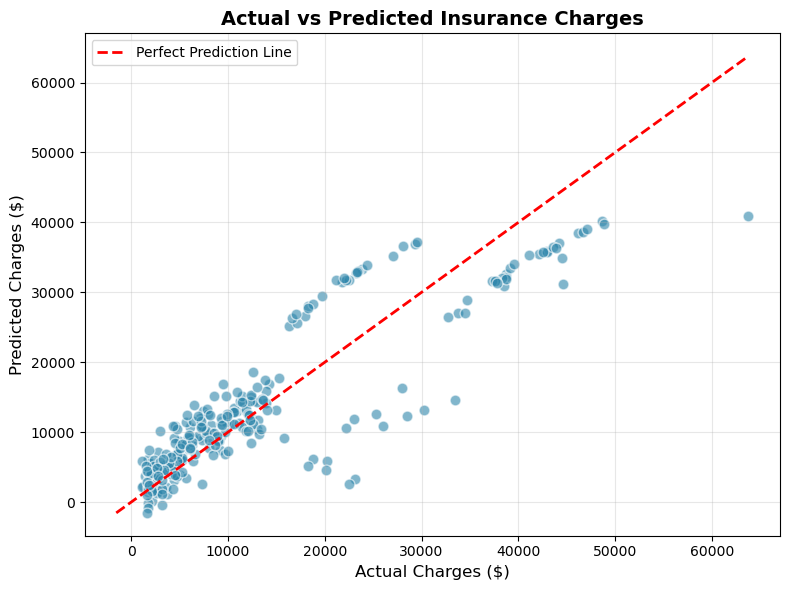

In [14]:
import matplotlib.pyplot as plt

# Create the Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#2E86AB', edgecolor='white', s=60)

# Add a 45-degree reference line: if a point sits exactly ON this line, the prediction was perfect
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.title('Actual vs Predicted Insurance Charges', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)  # saves the plot as an image file too
plt.show()


### Observations

1. **Smoking status is by far the strongest predictor of insurance charges.** The `smoker`
   coefficient is dramatically larger (in the tens of thousands) than any other feature,
   meaning that being a smoker adds a very large amount to predicted charges compared to a
   non-smoker with otherwise identical characteristics.
2. **The model explains roughly 78% of the variation in charges** (R² ≈ 0.78), which is a
   reasonably strong fit for a linear model, but it leaves about 22% of the variation
   unexplained — likely due to non-linear effects and interactions the model can't capture
   (see limitation below).
3. **`age` and `bmi` have smaller but still positive effects on charges**, while `region` and
   `sex` contribute relatively little — their coefficients are small compared to `smoker`,
   `bmi`, and `age`. In the scatter plot, most points cluster reasonably close to the
   "perfect prediction" line for non-smokers, but the model tends to under- or over-predict
   more for high-charge smokers, visible as points that fan out away from the red line at the
   higher end of the charge range.


---



### Conclusion

This project built a Multiple Linear Regression model to predict medical insurance charges
using age, sex, BMI, number of children, smoking status, and region. The model achieved an
R² score of approximately 0.78, meaning it explains about 78% of the variation in charges,
with a mean absolute error of roughly $4,180. The most influential factor by far was
**smoking status**, followed by **BMI** and **age**, while **sex** and **region** had much
smaller effects. These findings align with real-world expectations, since smoking and high
BMI are well-documented health risk factors that insurers price heavily into premiums. One
key limitation of Linear Regression here is that it assumes a purely **linear, additive**
relationship between features and charges, but in reality, factors like smoking and BMI
likely **interact** (e.g., a high BMI matters far more for a smoker than a non-smoker), which
a simple linear model cannot capture without manually adding interaction terms or using a
non-linear model instead.
